#### 6.1

Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
Number of HDUs: 2
Image HDU index: PrimaryHDU
First 5 header keywords:
SIMPLE True
BITPIX 16
NAXIS 2
NAXIS1 530
NAXIS2 530
BITPIX: 16
Shape: (530, 530)
dtype: >i2
NAXIS1: 530 NAXIS2: 530
Min: 1507
Max: 15752
Mean: 4795.924268422927
Std: 1848.2526085366376
Median: 4102.0
Mode: 3551


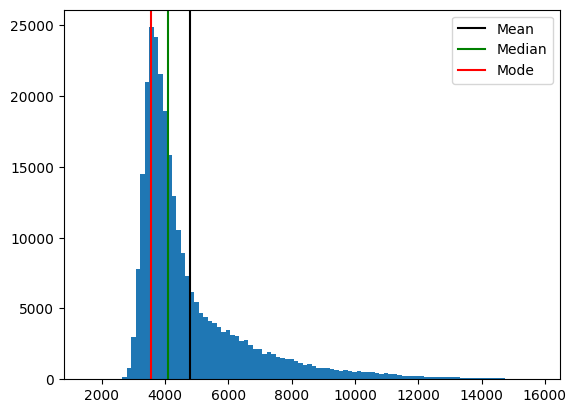

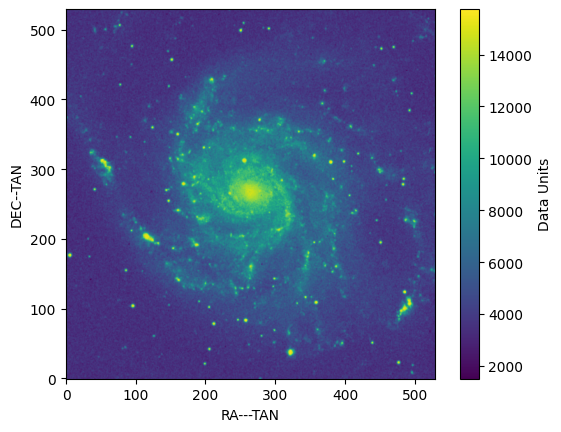

In [3]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#2

hdul = fits.open('m101.fits')
hdul.info()

print("Number of HDUs:", len(hdul))
print("Image HDU index: PrimaryHDU")
#Number type?

hdr = hdul[0].header
dat = hdul[0].data

#3

print("First 5 header keywords:")
for i, key in enumerate(hdr.keys()):
    if i < 5:
        print(key, hdr[key])


print("BITPIX:", hdr['BITPIX'])

#4

print("Shape:", dat.shape)
print("dtype:", dat.dtype)
print("NAXIS1:", hdr['NAXIS1'], "NAXIS2:", hdr['NAXIS2'])

flat = dat.flatten()

#5

print("Min:", np.min(flat))
print("Max:", np.max(flat))
print("Mean:", np.mean(flat))
print("Std:", np.std(flat))
print("Median:", np.median(flat))
mode = stats.mode(flat, keepdims=True)[0][0]
print("Mode:", mode)

#6

fig, ax = plt.subplots()
ax.hist(flat, bins=100)
ax.axvline(np.mean(flat), label='Mean', color='black')
ax.axvline(np.median(flat), label='Median', color='green')
ax.axvline(mode, label='Mode', color='red')
ax.legend()
plt.show()

#7

dat_float = np.asarray(dat, dtype=float)
med = np.median(dat_float)

fig, ax = plt.subplots()
im = ax.imshow(dat_float, origin='lower')
ax.set_xlabel(hdr['CTYPE1'])
ax.set_ylabel(hdr['CTYPE2'])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Data Units")
plt.show()

#8

hdr['BUNIT'] = 'Counts'
fits.PrimaryHDU(data=dat_float, header=hdr).writeto('m101_modified.fits', overwrite=True, output_verify='silentfix')

#### 6.3

In [61]:
import numpy as np
from astropy.io import fits

dat = fits.getdata('m101.fits').astype(float)

region = dat[0:20, 0:20]

rms = np.sqrt(np.mean(region**2))
mean = np.mean(region)
std = np.std(region)

print("RMS:", rms)
print("Mean:", mean)
print("Std:", std)

RMS: 3432.752866505248
Mean: 3422.8825
Std: 260.1300322795313


#### 6.5

In [7]:
import numpy as np
from astropy.io import fits

d0 = fits.getdata('noisemap0.fits')
d1 = fits.getdata('noisemap1.fits')
d2 = fits.getdata('noisemap2.fits')

print("Std d0:", np.std(d0))
print("Std d1:", np.std(d1))
print("Std d2:", np.std(d2))

stack = np.stack([d0, d1, d2], axis=0)
mean_img = np.mean(stack, axis=0)

print("Std of mean image:", np.std(mean_img))
print("Expected:", np.std(d0) / np.sqrt(3))

Std d0: 9.98401556679484
Std d1: 10.003955116338458
Std d2: 9.995349488722516
Std of mean image: 5.773191380233297
Expected: 5.764274075082415


#### 6.6

In [5]:
from astropy.io import fits
from astropy.table import Table, QTable
import numpy as np

hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data
colnames = hdul[1].columns.names
hdul.info()
flag = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

DATAFLAG = flag.astype(int)

table = Table(data)
table['DATAFLAG'] = DATAFLAG

parallax = data['GAIAEDR3_PARALLAX'] / 1000
distance = np.where(parallax > 0, 1 / parallax, np.nan)

M = data['GAIAEDR3_PHOT_G_MEAN_MAG'] - 5*np.log10(distance) + 5

M[DATAFLAG == 1] = -1.0

table['ABS_MAG'] = M

table.write('APOGEE_update.fits', overwrite=True)

img_data = hdul[0].data
img_header = hdul[0].header
print(img_data.shape)
print(img_data.dtype)
table_data = hdul[1].data
print(hdul[1].columns.names)

hdul2 = fits.open('APOGEE_update.fits')
hdul2.info()

Filename: APOGEE_stars.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (847,)   uint8   
  1  /Users/sunnyc/Downloads/allStar-dr17-synspec_rev1.fits#1    1 BinTableHDU     28   733901R x 8C   ['E', 'E', 'E', 'E', 'E', 'K', 'K', 'E']   
(847,)
uint8
['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']
Filename: APOGEE_update.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     28   733901R x 10C   [E, E, E, E, E, K, K, E, K, E]   


#### 6.7

    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


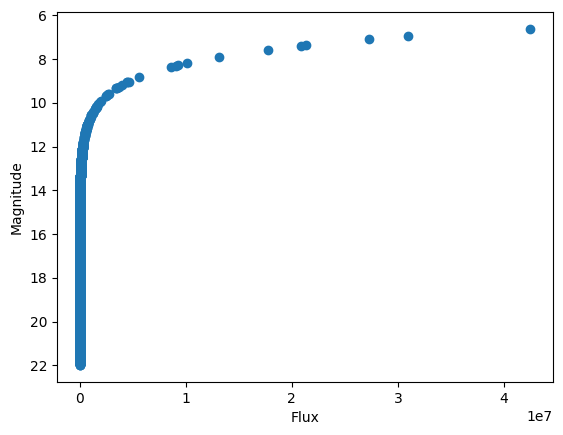

Estimated F0: 18852117942.14138


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('gaiaTestData.csv')

max_flux = df['phot_g_mean_flux'].max()
print(df[df['phot_g_mean_flux'] == max_flux])

df_sorted = df.sort_values('phot_g_mean_flux')

F = df['phot_g_mean_flux']
m = df['phot_g_mean_mag']
fig, ax = plt.subplots()
ax.set_xlabel('Flux')
ax.set_ylabel('Magnitude')
ax.invert_yaxis()
ax.scatter(F, m)
plt.show()
F0 = F * 10**(m/2.5)
print("Estimated F0:", np.mean(F0))

#### 6.10

In [6]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 50
source_id, ra, dec, parallax, parallax_error,
phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
"""

job = Gaia.launch_job(query)
results = job.get_results()

df = results.to_pandas()

results.write('astroquery_gaia.fits', overwrite=True)
df.head()

/Software/users/modules/9/software/anaconda3/2023.03/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.11.909) or chardet (4.0.0)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


,SOURCE_ID,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag
0,5050881701504,44.952938,0.133891,2.835756,0.137447,18.225672,19.889681,16.991913
1,9689446227072,45.182441,0.218552,1.496435,0.084581,16.613949,17.487335,15.679754
2,22814866348800,44.752846,0.284424,1.394892,0.165536,18.244738,19.253035,17.189337
3,25980257976960,44.850926,0.398492,1.987432,0.225709,11.724028,12.090870,10.976363
4,29652454445824,45.134739,0.481885,0.570393,0.112279,17.711603,18.151184,17.090889


#### 6.14

In [60]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self, N, M):
        self.N = N #Number
        self.M = M #Division number

    def nthterm(self):
        a, b = 0, 1
        for i in range(self.N-2):
            a, b = b, a + b
        return a

    def divisible(self):
        a , b = 0, 1
        result = []
        
        n = self.nthterm()
        while a < n:
            a, b = b, a + b
            if a % self.M == 0:
                result.append(a)
        return result
        
fib = Fibonacci(100, 7)

print(fib.nthterm())

print(fib.divisible())

135301852344706746049
[21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
